In [1]:
import os
import ast
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
DATA_ROOT = '.\\ptb-xl'
CSV_PATH = os.path.join(DATA_ROOT, 'ptbxl_database.csv')
SCP_PATH = os.path.join(DATA_ROOT, 'scp_statements.csv')
RECORDS100 = os.path.join(DATA_ROOT, 'records100')
RECORDS500 = os.path.join(DATA_ROOT, 'records500')

In [3]:
record = wfdb.rdrecord('.\\ptb-xl\\records100\\00000\\00001_lr')  # Load the signal
annotation = wfdb.rdann('.\\ptb-xl\\records100\\00000\\00001_lr', 'hea')  # Load annotations
wfdb.plot_wfdb(record=record, annotation=annotation)

Exception: IndexError: try setting shift_samps=True in the "rdann" function?

In [3]:
df = pd.read_csv(CSV_PATH, index_col='ecg_id')
df.head(3)

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr


In [4]:
df['scp_codes'] = df['scp_codes'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else {})

print('Total records in CSV:', len(df))
print('Unique patients:', df.patient_id.nunique())
print('Age (median, IQR):', df.age.median(), df.age.quantile([0.25, 0.75]).values)

df['scp_codes'].head(3)

Total records in CSV: 21799
Unique patients: 18869
Age (median, IQR): 62.0 [50. 72.]


ecg_id
1    {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
2                {'NORM': 80.0, 'SBRAD': 0.0}
3                  {'NORM': 100.0, 'SR': 0.0}
Name: scp_codes, dtype: object

In [5]:
agg_df = pd.read_csv(SCP_PATH, index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

df['diagnostic_superclass'] = df.scp_codes.apply(aggregate_diagnostic)

df[['scp_codes','diagnostic_superclass']].head(6)

,scp_codes,diagnostic_superclass
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM]
2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM]
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
4,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
5,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
6,"{'NORM': 100.0, 'SR': 0.0}",[NORM]


In [6]:
from collections import Counter
counter = Counter()
for sup in df['diagnostic_superclass']:
    counter.update(sup)
pd.Series(counter).sort_values(ascending=False)

NORM    9514
MI      5469
STTC    5235
CD      4898
HYP     2649
dtype: int64

In [7]:
sample_ecg_id = df.index[0]
fn = df.loc[sample_ecg_id, 'filename_lr']
fullpath = os.path.join(DATA_ROOT, fn)
signal, meta = wfdb.rdsamp(fullpath)
print('record path:', fullpath)
print('signal.shape:', signal.shape)
print('meta keys:', list(meta.keys()))

record path: .\ptb-xl\records100/00000/00001_lr
signal.shape: (1000, 12)
meta keys: ['fs', 'sig_len', 'n_sig', 'base_date', 'base_time', 'units', 'sig_name', 'comments']


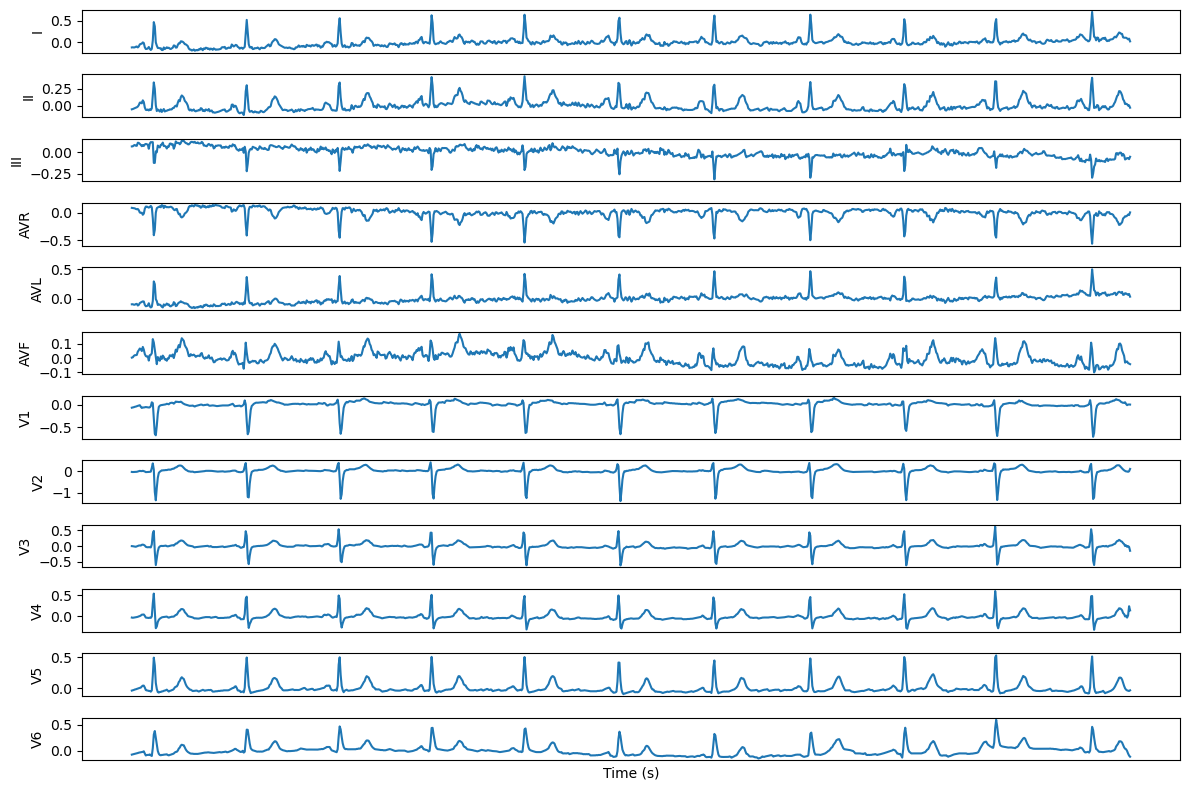

In [8]:
plt.rcParams['figure.figsize'] = (12, 8)
sig = signal
n_samples, n_leads = sig.shape
time = np.arange(n_samples) / meta['fs']
lead_names = meta.get('sig_name', [f'L{i}' for i in range(n_leads)])
for i in range(n_leads):
    plt.subplot(n_leads, 1, i+1)
    plt.plot(time, sig[:, i])
    plt.ylabel(lead_names[i])
    plt.xticks([])
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [9]:
import glob
files = sorted(glob.glob(os.path.join(RECORDS100, '*', '*_lr.dat')))

sample_counts = []
for f in tqdm(files[:2000]):
    recname = f[:-4]
    try:
        sig, meta = wfdb.rdsamp(recname)
        sample_counts.append(sig.shape)
    except Exception as e:
        print('error reading', recname, e)

pd.Series(sample_counts).value_counts().head()

  0%|          | 0/2000 [00:00<?, ?it/s]

(1000, 12)    2000
Name: count, dtype: int64